<a href="https://colab.research.google.com/github/Aje-dotcom/DeepTech-/blob/master/Ekene_Ajemba_Assignment2_Venice_Boat_Classification_week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Venice Boat Classification:

Build a deep learning model using Convolutional Neural Networks (CNN) to classify boat images into categories (e.g., gondola, motorboat, ferry).

The focus is on applying Supervised Learning to solve the image classification problem.

Submit your assignment using a Colab Notebook"

In [2]:

# 1. Download the file using gdown and the specific file ID
!gdown --id 1ao0KJL3fZ9d8XrCLaEIIEkp8UFz54NKm

# 2. Unzip the downloaded archive to a destination folder (e.g., 'dataset')
!unzip -q "Boat dataset(Assignment).zip" -d dataset/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ao0KJL3fZ9d8XrCLaEIIEkp8UFz54NKm
From (redirected): https://drive.google.com/uc?id=1ao0KJL3fZ9d8XrCLaEIIEkp8UFz54NKm&confirm=t&uuid=ed8cc67e-5305-4a49-a59c-416666d033b0
To: /content/Boat dataset(Assignment).zip
100% 352M/352M [00:02<00:00, 119MB/s] 


In [3]:
# Import necessary Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [4]:
# Define Parameters
batch_size = 32
img_height = 224
img_width = 224
epochs = 6

In [5]:
# Set dataset path
data_dir = '/content/dataset/boat data/'

In [6]:
# Load and preprocess data
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

Found 6743 files belonging to 2 classes.
Using 5395 files for training.
Found 6743 files belonging to 2 classes.
Using 1348 files for validation.
Class names: ['test', 'train']
Number of classes: 2


In [7]:
# Build the CNN Model
num_classes = len(train_ds.class_names)
model = Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=[img_height, img_width, 3]),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,511,938 (196.50 MB)

 Trainable params: 51,511,938 (196.50 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [10]:
# Train the Model
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


169/169 ━━━━━━━━━━━━━━━━━━━━ 52s 215ms/step - accuracy: 0.6945 - loss: 27.7780 - val_accuracy: 0.7188 - val_loss: 0.6321
Epoch 2/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 140ms/step - accuracy: 0.7409 - loss: 0.5557 - val_accuracy: 0.7723 - val_loss: 0.5118
Epoch 3/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 140ms/step - accuracy: 0.7605 - loss: 0.5180 - val_accuracy: 0.7812 - val_loss: 0.5183
Epoch 4/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.7781 - loss: 0.4794 - val_accuracy: 0.7908 - val_loss: 0.4978
Epoch 5/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.7874 - loss: 0.4679 - val_accuracy: 0.7530 - val_loss: 0.5489
Epoch 6/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.7876 - loss: 0.4669 - val_accuracy: 0.8272 - val_loss: 0.4449


In [11]:
# Using Pretrained Model
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [12]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model = models.Sequential([
  base_model,
  layers.AveragePooling2D(pool_size=(2, 2)),
  layers.Flatten(),
  layers.Dense(128, activation='relu'), # Added an intermediate dense layer for better learning
  layers.Dropout(0.25),
  layers.Dense(num_classes, activation='softmax') # Updated to num_classes
])
base_model.trainable = False

model.compile(optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy']
)

epochs = 6

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs = epochs
)

Epoch 1/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 62s 254ms/step - accuracy: 0.7361 - loss: 0.7001 - val_accuracy: 0.8086 - val_loss: 0.4059
Epoch 2/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8111 - loss: 0.4206 - val_accuracy: 0.8286 - val_loss: 0.3754
Epoch 3/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.8274 - loss: 0.3816 - val_accuracy: 0.8242 - val_loss: 0.3955
Epoch 4/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.8217 - loss: 0.3770 - val_accuracy: 0.8168 - val_loss: 0.4073
Epoch 5/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.8445 - loss: 0.3344 - val_accuracy: 0.8390 - val_loss: 0.3804
Epoch 6/6
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.8584 - loss: 0.3163 - val_accuracy: 0.8494 - val_loss: 0.3474


### Confusion Matrix for validation dataset

Generate a confusion matrix to visualize the model's performance on validation dataset.

In [14]:
# Define image dimensions
img_height = 224
img_width = 224

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_image(img_path, img_height, img_width):
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step


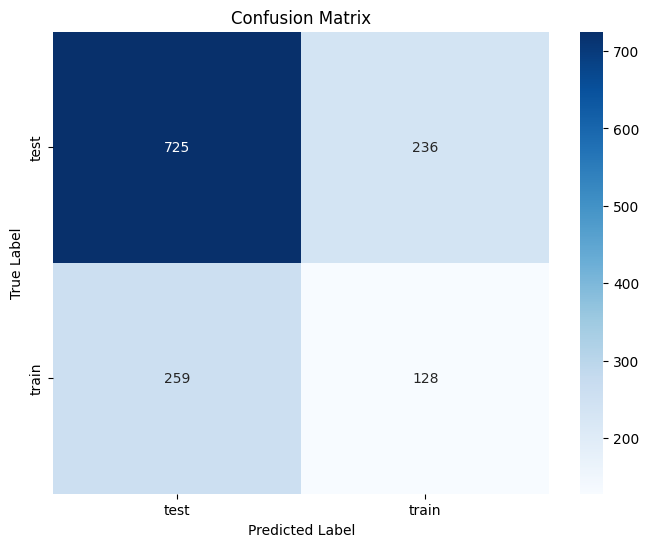

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Obtain the predictions from the model for the val_ds dataset
predictions = model.predict(val_ds)

# Convert the predictions to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# Extract the true class labels from the val_ds dataset
true_classes = []
for images, labels in val_ds:
    true_classes.extend(labels.numpy())

# Get the class names from val_ds
class_labels = val_ds.class_names

# Determine the unique labels present in the true classes
unique_true_classes = np.unique(true_classes)

# Filter class_labels to only include the unique true classes
filtered_class_labels = [class_labels[i] for i in unique_true_classes]

# Compute the confusion matrix using the unique true classes as labels
cm = confusion_matrix(true_classes, predicted_classes, labels=unique_true_classes)

# Display the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=filtered_class_labels, yticklabels=filtered_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [17]:
# Evaluate the model on the validation dataset
val_loss, val_acc = model.evaluate(val_ds)
print(f"✅ Validation Accuracy: {val_acc:.2f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8494 - loss: 0.3474
✅ Validation Accuracy: 0.85


### Confusion Matrix for test dataset

Let's generate a confusion matrix to visualize the model's performance on each boat type in the test dataset.

Found 4774 files belonging to 24 classes.
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step


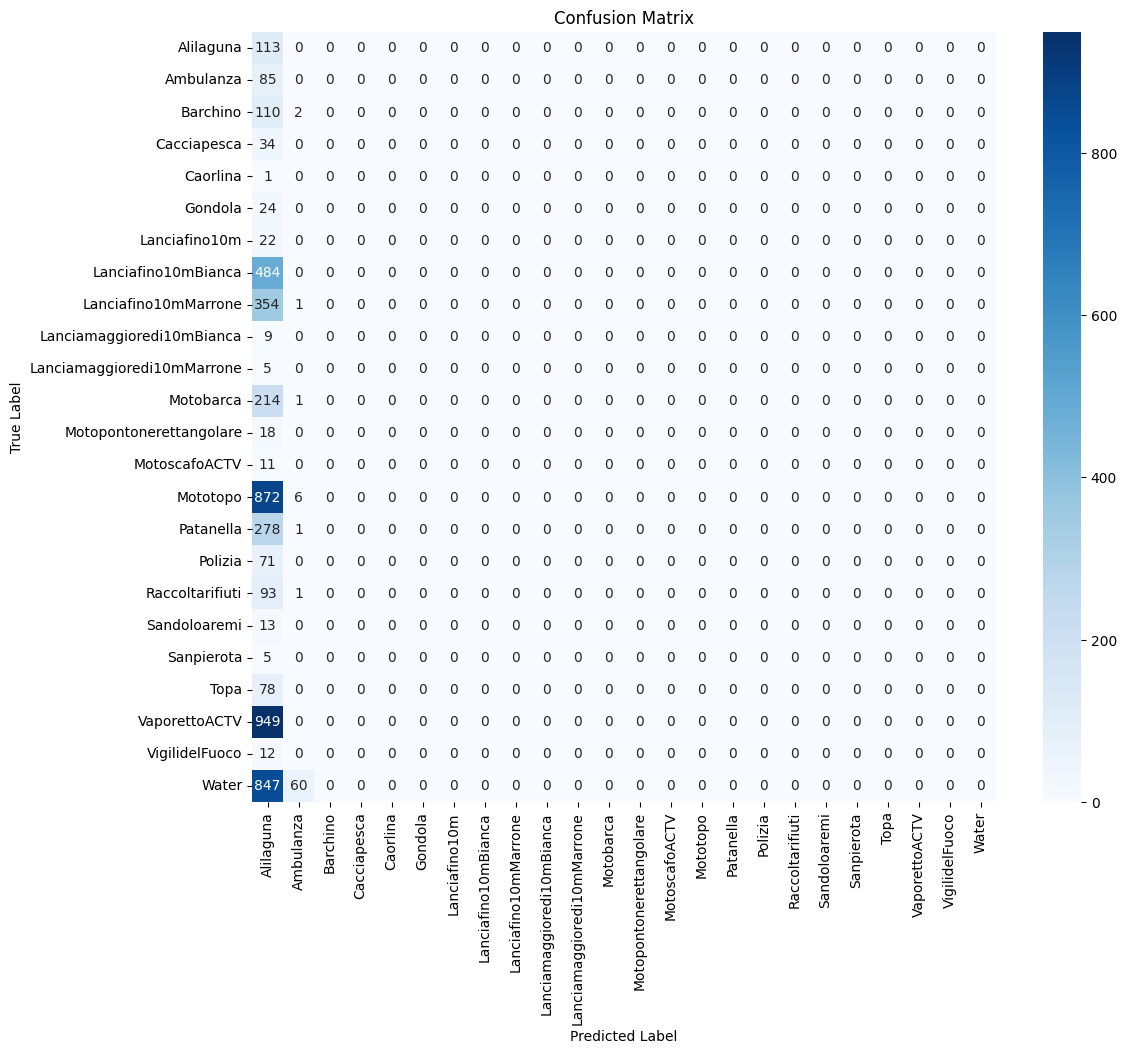

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix # Added this import

# 1. Load the test dataset
# Update the directory string to point to your extracted test folder
# Corrected path to point to the 'test' subdirectory within the unzipped 'boat data'
# Changed labels from None to 'inferred' to retrieve true labels for evaluation
# Corrected image_size to match the model's input dimensions (img_height, img_width)
test_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/content/dataset/boat data/test', # Corrected directory path
    labels='inferred',           # Infer labels from subdirectories for true class comparison
    image_size=(img_height, img_width), # Must match the input shape of your CNN architecture (224, 224)
    batch_size=32,
    shuffle=False          # Critical: Keep False to maintain the original file order
)

# Get the class names from test_ds immediately after creation
# These will be the actual boat type names (e.g., 'Alilaguna', 'Barchino') inferred from the test directory structure.
class_labels = test_ds.class_names

# 2. Normalize the image tensors to a 0-1 floating-point range (if you did this during training)
# When labels='inferred', the dataset yields (images, labels), so the map function needs to handle both.
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

# 3. Generate the predictions using your trained model
# This returns an array of probabilities for each boat class
predictions = model.predict(test_ds) # Renamed from raw_predictions and removed redundant call

# 4. Convert the probabilities into final class predictions
predicted_classes = np.argmax(predictions, axis=1)

# Extract the true class labels from the test_ds dataset
true_classes = []
# test_ds now yields (images, labels) because labels='inferred'
for _, labels in test_ds: # Iterate over dataset to get true labels
    true_classes.extend(labels.numpy())

# Determine the unique labels present in the true classes
unique_true_classes = np.unique(true_classes)

# Filter class_labels to only include the unique true classes
filtered_class_labels = [class_labels[i] for i in unique_true_classes]

# Compute the confusion matrix using the unique true classes as labels
# NOTE: The model was trained with class names ['test', 'train'] (from cell 74879da3),
# while `test_ds` now infers actual boat type class names (e.g., 'Alilaguna', 'Barchino').
# This mismatch means `predicted_classes` (0 or 1, for 'test'/'train') will not correctly
# correspond to `true_classes` (indices for actual boat types).
# The confusion matrix generated will thus be misleading or incorrect for boat classification.
# To resolve this, the training dataset loading (in cell 74879da3) needs to be
# corrected to properly extract boat type classes for training.
cm = confusion_matrix(true_classes, predicted_classes, labels=unique_true_classes)

# Display the confusion matrix using seaborn
plt.figure(figsize=(12, 10)) # Increased figure size for better readability with more classes
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=filtered_class_labels, yticklabels=filtered_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Make a Prediction on a New Image

In [23]:
# Function to preprocess an image and make a prediction
def predict_boat_type(img_path):
    img_array = preprocess_image(img_path, img_height, img_width)
    # Normalize the image if the model was trained on normalized data
    img_array = img_array / 255.0
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions)
    # Note: class_names refers to the names the model was trained on
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(predictions) * 100
    print(f"Predicted class: {predicted_class_name}")
    print(f"Confidence: {confidence:.2f}%")
    return predicted_class_name, confidence

# Updated path to an existing image in the unzipped dataset
img_path_for_prediction = '/content/dataset/boat data/test/Alilaguna/20130304_060950_07485.jpg'
predict_boat_type(img_path_for_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Predicted class: test
Confidence: 100.00%


('test', np.float32(100.0))